In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2
from keras import layers, models

In [9]:
# 1. Prétraitement et augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "fruits_dataset/",
    target_size=(128,128),
    batch_size=16,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    "fruits_dataset/",
    target_size=(128,128),
    batch_size=16,
    class_mode="categorical",
    subset="validation"
)

Found 237 images belonging to 10 classes.
Found 54 images belonging to 10 classes.


In [10]:
# 2. Transfer learning avec MobileNetV2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(128,128,3))
base_model.trainable = False  # geler les couches pour éviter le surapprentissage

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [11]:
# 3. Entraînement
history = model.fit(train_gen, validation_data=val_gen, epochs=30)
# model.save("model_cnn.h5")  # format HDF5

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 905ms/step - accuracy: 0.1688 - loss: 2.6621 - val_accuracy: 0.3519 - val_loss: 1.9233
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 444ms/step - accuracy: 0.3924 - loss: 1.7287 - val_accuracy: 0.4815 - val_loss: 1.4792
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accuracy: 0.5696 - loss: 1.4233 - val_accuracy: 0.4074 - val_loss: 1.4709
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 412ms/step - accuracy: 0.5696 - loss: 1.1832 - val_accuracy: 0.5370 - val_loss: 1.3267
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 450ms/step - accuracy: 0.6540 - loss: 1.0710 - val_accuracy: 0.4815 - val_loss: 1.3337
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 430ms/step - accuracy: 0.6793 - loss: 0.9108 - val_accuracy: 0.6296 - val_loss: 1.1849
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 416ms/step - accuracy: 0.7637 - loss: 0.7570 - val_accuracy: 0.5741 - val_loss: 1.2024
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 561ms/step - accuracy: 0.7637 - loss: 0.7132 - val_accuracy: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 895ms/step


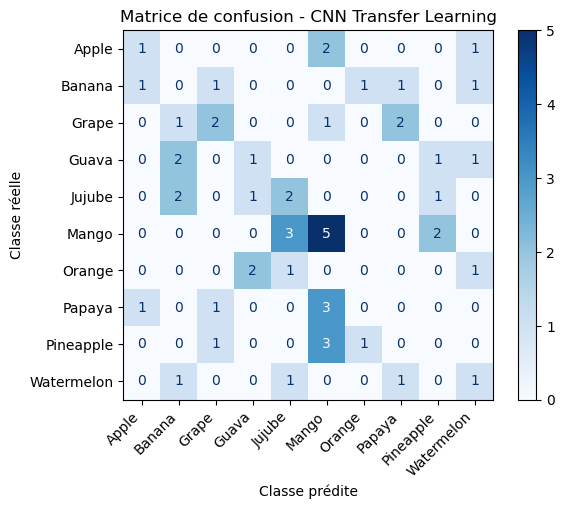

In [12]:
# 5. Matrice de confusion
y_true = val_gen.classes
y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(val_gen.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de confusion - CNN Transfer Learning")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")

# Rotation des labels de l'axe X pour éviter le chevauchement
plt.xticks(rotation=45, ha="right")

plt.show()


In [13]:
# 6. Prédiction sur une nouvelle image
img_path = "C:\\Users\\PC\\Downloads\\CC_FASTAPI\\Fruits_dataset\\Apple\\Apple_1.jpg"  # mets ton image ici
img = load_img(img_path, target_size=(128,128))
x = img_to_array(img)
x = np.expand_dims(x, axis=0) / 255.0
prediction = model.predict(x)
pred_class = np.argmax(prediction, axis=1)[0]
class_labels = list(train_gen.class_indices.keys())
print(f"Le modèle prédit que le fruit est: {class_labels[pred_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Le modèle prédit que le fruit est: Apple
